In [3]:
import os
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from statsmodels.tsa.seasonal import seasonal_decompose

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from coreforecast.scalers import boxcox, boxcox_lambda
from utilsforecast.losses import rmse, mae, smape
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from statsforecast.models import AutoETS
from statsforecast.arima import ndiffs, nsdiffs
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import ARIMASummary
from copy import deepcopy

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown, Image

from fpppy.utils import plot_series

# endregion 
from plotnine import *

# change working directory 
# Check if current directory has any .ipynb files
if any(fname.endswith(".ipynb") for fname in os.listdir()):
    os.chdir("..")

# load local package modules
from gas_pump_prices.preprocess import * 

%load_ext autoreload
%autoreload 2

## 9.1. Stationarity and differencing 

Stationary time series have statistical properties that do not deend on time. Stated simply, stationary time series do not have trends or seasonaality components. Statistically, the mean and variance do not change over time (this does not necessarily imply a zero-value mean).

Differencing is one method commonly used to stabilize the mean of a non-stationary series and logarithms offer a method to stabilize variances. 

$$
y^\prime = y_t - y_{t-1}
$$

Sometimes, second-order differencing is needed to render a time series stationary.

$$
\begin{aligned}
y^{\prime\prime} &= y^\prime - y^\prime_{t-1} \\ 
&= (y_t - y_{t-1}) - (y_{t-1} - y_{t-2}) \\ 
&= y_t - 2y_{t-1} + y_{t-2}
\end{aligned}
$$

### Random walk model 

Random walk models simply use the previous observation as the prediction for the next observation. Therefore, 

$$
y_t = y_{t-1} + \epsilon_t.
$$

Random walk models provide naïve forecasts and are oftentimes used in financial data. Random walk time series are characterized by long periods of upward/downward trends marked by sudden changes in direction. 

Drift methods can easily be obtained from random walk models by simpling allowing for non-zero differences between consecutive observations. 

$$
\begin{aligned}
y_t - y_{t-1} &= c + \epsilon_t \\
y_t &= c + y_{t-1} + \epsilon_t
\end{aligned}
$$

### Seasonal differencing 

Seasonal differencing removes any variability due to seasons. Each time points value from the prior season is subtracted 

$$
y^\prime = y_t - y_{t-m}, 
$$

where $m$ is the number of seasons. 


Sometimes, multiple methods of differencing are needed to obtained a stationary time series. The below example takes the log of corticosteroid sales and then applies two rounds of seasonal differncing. Although formal tests exist for determining whehter a time series is stationary, there is always a subjective element involved. 

Two important notes: 
1) Applying too many differencing methods can cause spurious relations in the data, and so the goal should be to only apply as little differencing as needed. 
2) Differenced data should remain interpretable. Don't just try out differencing lags that do not make sense in the given context. 

,ds,Concession,Type,ATC1,ATC1_desc,ATC2,ATC2_desc,Scripts,Cost
0,1991-07-01,Concessional,Co-payments,H,"Systemic hormonal preparations, excl. sex horm...",H02,CORTICOSTEROIDS FOR SYSTEMIC USE,63261,317384.0
1,1991-08-01,Concessional,Co-payments,H,"Systemic hormonal preparations, excl. sex horm...",H02,CORTICOSTEROIDS FOR SYSTEMIC USE,53528,269891.0
2,1991-09-01,Concessional,Co-payments,H,"Systemic hormonal preparations, excl. sex horm...",H02,CORTICOSTEROIDS FOR SYSTEMIC USE,52822,269703.0
3,1991-10-01,Concessional,Co-payments,H,"Systemic hormonal preparations, excl. sex horm...",H02,CORTICOSTEROIDS FOR SYSTEMIC USE,54016,280418.0
4,1991-11-01,Concessional,Co-payments,H,"Systemic hormonal preparations, excl. sex horm...",H02,CORTICOSTEROIDS FOR SYSTEMIC USE,49281,268070.0
...,...,...,...,...,...,...,...,...,...
811,2008-02-01,General,Safety net,H,"Systemic hormonal preparations, excl. sex horm...",H02,CORTICOSTEROIDS FOR SYSTEMIC USE,1925,11564.0
812,2008-03-01,General,Safety net,H,"Systemic hormonal preparations, excl. sex horm...",H02,CORTICOSTEROIDS FOR SYSTEMIC USE,258,1719.0
813,2008-04-01,General,Safety net,H,"Systemic hormonal preparations, excl. sex horm...",H02,CORTICOSTEROIDS FOR SYSTEMIC USE,268,3883.0
814,2008-05-01,General,Safety net,H,"Systemic hormonal preparations, excl. sex horm...",H02,CORTICOSTEROIDS FOR SYSTEMIC USE,593,4594.0


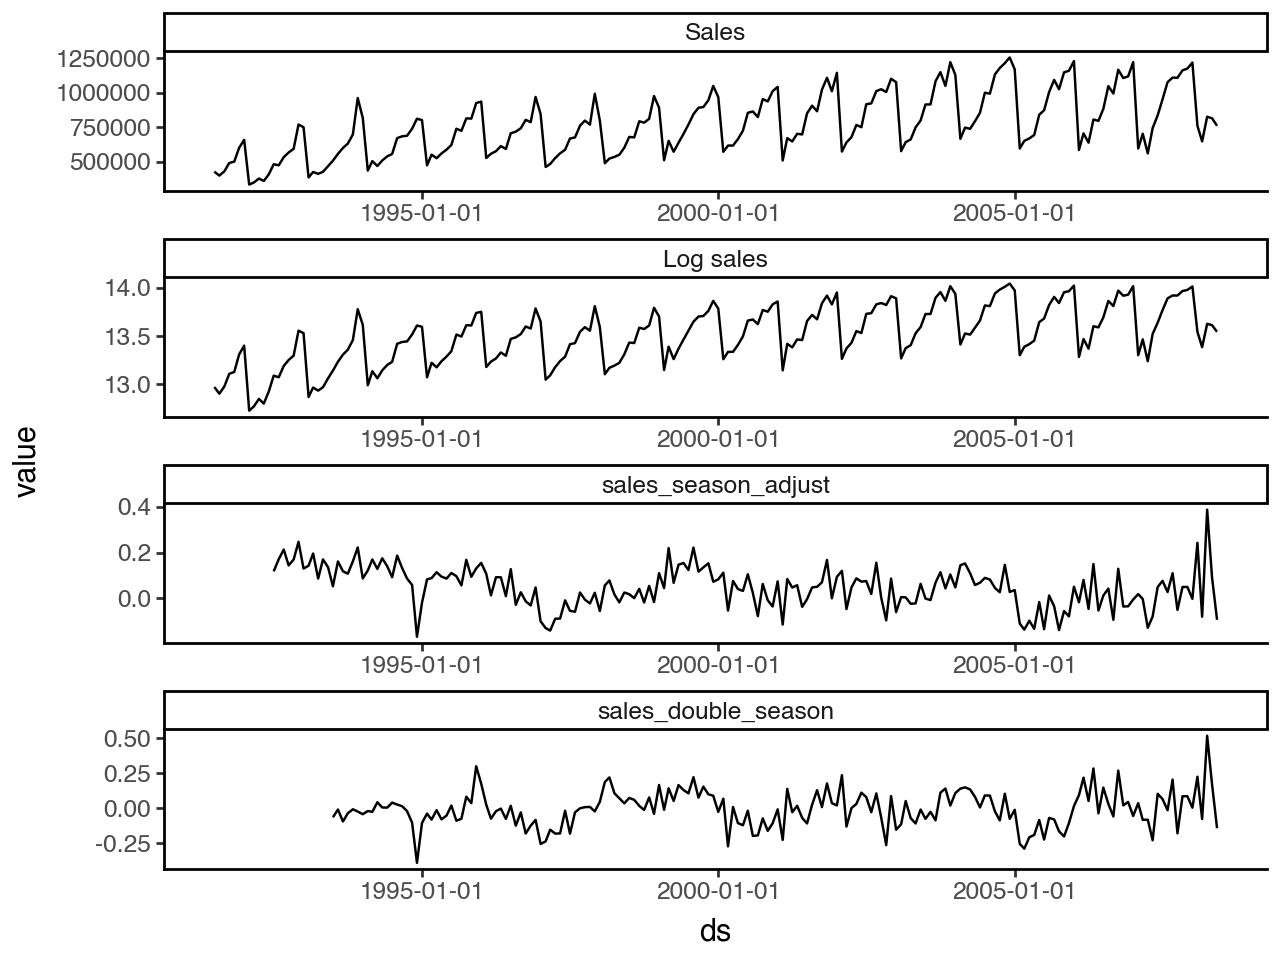

In [ ]:
# Example: Apply differencing methods on corticosteroid data
df_steroid = pd.read_csv('data/raw/PBS_unparsed.csv', parse_dates=['Month']) 

df_steroid = df_steroid.rename(columns={"Month": "ds"})
df_steroid = df_steroid.query("ATC2 == 'H02'").reset_index(drop=True)

# collapse across all different merdication types
df_steroid = df_steroid.groupby(["ds"])["Cost"].sum().reset_index()
df_steroid = df_steroid.rename(columns={"Cost": "Sales"})
df_steroid["Log sales"] = np.log(df_steroid["Sales"])
df_steroid["sales_season_adjust"] = df_steroid["Log sales"].diff(periods=12)
df_steroid["sales_double_season"] = df_steroid["sales_season_adjust"].diff(periods=12)

df_long = df_steroid.melt(id_vars=['ds'], value_name='value', var_name='var_type')
df_long['var_type'] = pd.Categorical(values=df_long['var_type'],
                                     categories=['Sales', 'Log sales', 'sales_season_adjust', 'sales_double_season'], 
                                      ordered=True)


(ggplot(data=df_long, mapping=aes(x='ds', y='value')) + 
    geom_line() + 
    facet_wrap(facets='~var_type', scales='free', ncol=1) + 
    theme_classic())

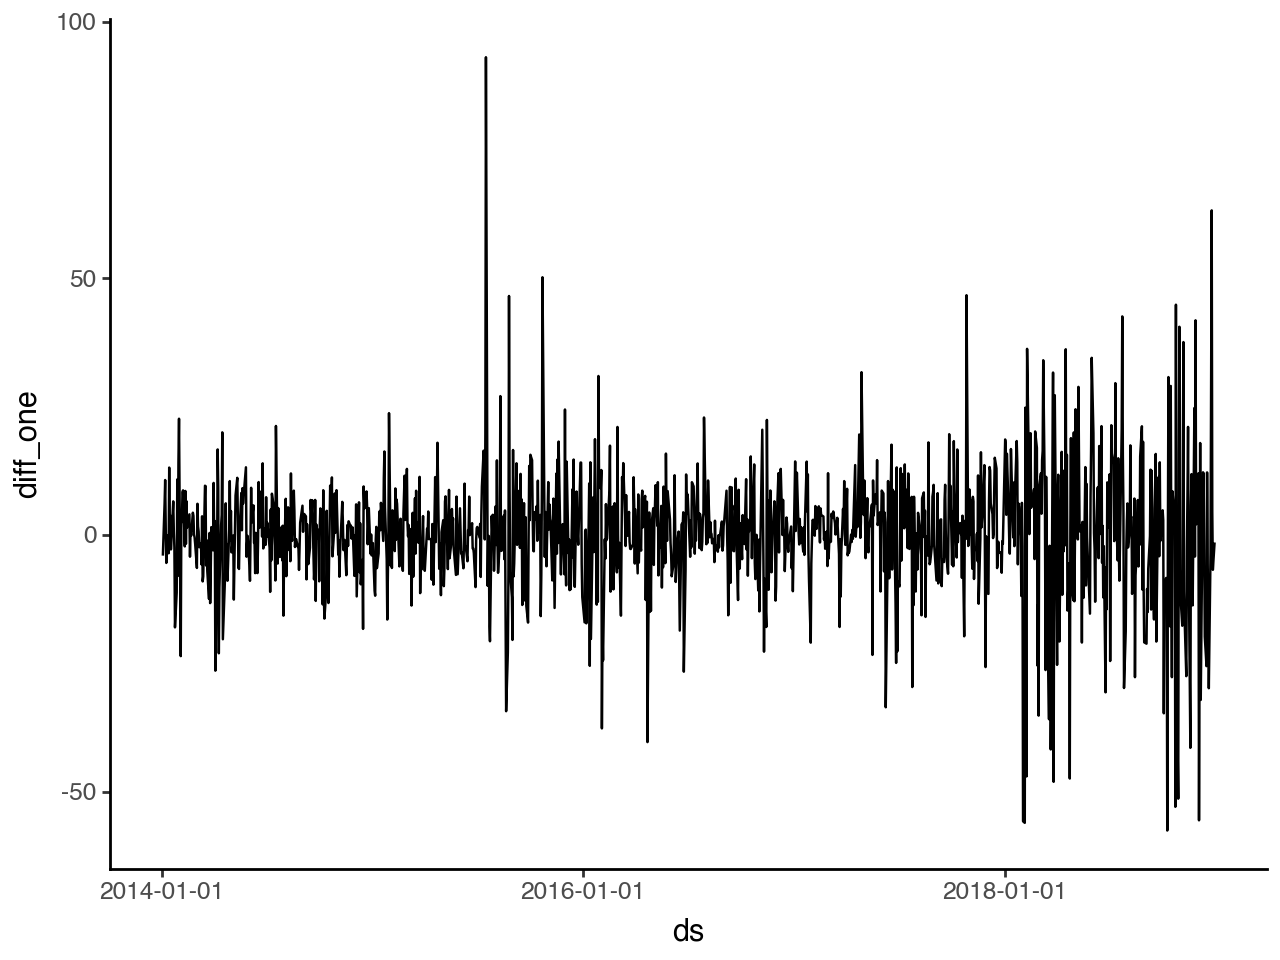

In [ ]:
# Example: First-order differencing on Google stock data
df_stock = pd.read_csv('data/raw/gafa_stock.csv', parse_dates=['ds'])
df_goog = df_stock.loc[df_stock['unique_id'].eq('GOOG_Close')]

df_goog['diff_one'] = df_goog['y'].diff(periods=1)

(ggplot(data=df_goog, mapping=aes(x='ds', y='diff_one')) + 
    geom_line() + 
    theme_classic())

### Unit root tests

Authors recommend using the Kwiatkowski-Phillis-Schmidt-Shin (KPSS). Given that the null hypothesis is that the data are stationary, *p* value < .05 suggests differencing is needed.

Couple of notes: 
1. The `nlags` parameter specifies the number of lags used in testing whether variance is homoscedastic. 
2. *p* values are reported as either (at most).01 or .1 (at least) to simplify decision making. 
3. `ndiffs()` indicates the number of first differences needed and `nsdiffs()` indicates the number of seasonal differencing required. If 

In [37]:
# examine output with original data and differenced data 
goog_kpss_stat, goog_kpss_pvalue, _, _ = kpss(df_goog["y"], nlags='auto')
print(f"kpss_stat: {goog_kpss_stat:.3f}, kpss_pvalue: {goog_kpss_pvalue:.2f}")

goog_kpss_stat, goog_kpss_pvalue, _, _ = kpss(df_goog["y"].diff()[1:], nlags='auto')
print(f"kpss_stat: {goog_kpss_stat:.3f}, kpss_pvalue: {goog_kpss_pvalue:.2f}")

# number of seasonal differencing required 
nsdiffs(df_steroid["Log sales"].values, period=12)
nsdiffs(df_steroid["sales_season_adjust"].values, period=12)


kpss_stat: 5.452, kpss_pvalue: 0.01
kpss_stat: 0.049, kpss_pvalue: 0.10


1

0

## 9.2. Backshift notation 

$n^{th}$-order differencing can be expressed as 

$$
(1-B)^ny y_t
$$

Backshift notation becomes especially useful when combining differencing methods. For example, a seasonal difference followed by a first-order difference can be defined as 

$$
(1-B)(1-B^m)y_t
$$

## 9.3. Autoregressive models

Future values are predicted using prior values of the variable. 

$$
y_t = c + \phi^1 y_{t-1} + ... + \phi^p y_{t-p} + \epsilon_t
$$

The above model is referred to as an **AR(p) model**, an AutoRegressive model of order p. 

Couple of notes for an AR(1) model: 

1. Model is equivalent to white noise when $c=0$ and $\phi_1=0$. 
2. Model is equivalent to random walk when $c=0$ and $\phi_1=1$. 
3. Model is equivalent to random walk with drift when $c\ne0$ and $\phi_1=1$. 
4. Model predictions tend to oscillate around the mean when $\phi_1 \lt 0$ 

In general, estimates of $phi_n$ are constrained to ensure AR(p) model predictinos assume stationarity data. 

## 9.4. Moving average models 

Future values are predicted using prior forecasting errors. 

$$
y_t = c + \theta^1 \epsilon_{t-1} + ... + \theta^q \epsilon_{t-q} + \epsilon_t
$$

The above model is referred to as an **MA(q) model**, an Moving Average model of order q. Importantly, MA(q) models should not be confused with moving average smoothing models, as the former are used to forecast future values, whereas the latter are used to estimate trend-cycle components. 

As long as $-1 \lt \phi_1 \lt 1$, any AR(p) model can be written as an MA($\infty$) model. As an example, 

$$
\begin{aligned}
y_t &= \phi_1 y_{t-1} + \epsilon_t \\ 
&= \phi_1 (y_{t-2} + \epsilon_{t-1} + \epsilon_t \\ 
&= \phi_2 y_{t-2} \phi_2 \epsilon_{t-1}  + \epsilon_{t-1} + \epsilon_t \\ 
&= \phi_3 t_{t-3} + \phi_3 \epsilon_{t-2} + \phi_2 \epsilon_{t-1}  + \epsilon_{t-1} + \epsilon_t
\end{aligned}
$$

Similarly, MA(q) models can be expressed as AR(p) models given similar constraints. 

**Invertibility** means that 

1. Parameter estimates are unique. Otherwise, different MA(q) models can generate the same autocovariance structure underlying a given AR(p) model. 
2. Estimates are stable. Because closed-form solutions exist, then estimation procedures won't wander aimlessly. 
3. ee 

## 9.5. Non-seasonal ARIMA models

Autoregressive and moving average models can be combined to produce AutoRegressive Integrated Moving Average models. In this case, models are non-seasonal.  The full model is written as 

$$
y^\prime_t = c + \theta^1 y^\prime_{t-1} + ... + \theta^q y^\prime_{t-q} + \phi^1 \epsilon_{t-1} + ... + \phi^p \epsilon_{t-p} + \epsilon_t
$$

where $y^\prime_t$ is the differenced time series. This is an **ARIMA(p, d, q)**  model where 

* p = order of autoregressive part (how many prior forecast errors are considered)
* d = degree of first differencing invovled
* q = order of the moving average part 


The following models can be reexpressed as instances of the ARIMA model: 

1. White noise = ARIMA(0, 0, 0) with no constant
2. Random walk = ARIMA(0, 1, 0) with no constant
3. Random walk with drift = ARIMA(0, 1, 0) with a constant
4. Autoregression = ARIMA(p, 0, 0) 
5. Moving average = ARIMA(0, 0, q) 

Note that `AutoArima()` automatically selects values for p, d, and q. 

### Example: Egyptian exports

The optimizer picks an ARIMA(2, 0, 1) where by each $t$ observation is predicted using 

$$
\begin{aligned}
y_t &= c + \phi^1 \epsilon_{t-1} + \phi^2 \epsilon_{t-2} + \theta^1 y_{t-1} + \epsilon_t \\ 
&= c + 1.68\epsilon_{t-1}  -0.80\epsilon_{t-2} -.69y_{t-1} + \epsilon_t, 
\end{aligned}
$$

where the standard deviation of $\epsilon_t$ is $\sqrt{8.05}$. 

As an aside, the estimate for the intercept requires a deeper understanding of stationarity. Under weak stationarity, the mean ($\mu$) is constant over time and the residuals are centerd on zero. That is, $\mathbb{E}[y_t] = \mu$ and $\mathbb{E}[\epsilon_t] = 0$. Therefore, the expectation of the above (unconditional) equation for $y_t$ can be taken to obtain 

$$
\begin{aligned}
\mu &= c + \phi^1 \mu + \phi^2 \mu + \theta^1 \mathbb{E}_t + \mathbb{E}_t  \\ 
&= c + \mu( \phi^1 +  \phi^2) \\ 
c &= \mu(1 -  \phi^1 -  \phi^2)
\end{aligned}
$$

Therefore, $c = 20.18(1 - 1.68 + .8) = 2.56$


In [18]:
# Example: Egyption exports 
df_econ = pd.read_csv("data/raw/global_economy.csv", parse_dates=[2])
df_econ = df_econ.rename(columns={"Exports": "y"})
df_egypt = df_econ.query("Code == 'EGY'").reset_index(drop=True)


# NOTE: non-zero mean models are considered (i.e., allow an intercept)
# NOTE: n_jobs indicates number of CPU cores to use 
models = [AutoARIMA(allowmean=True)]
sf = StatsForecast(models=models, freq="A", n_jobs=-1)
sf.fit(df=df_egypt[["ds", "y", "unique_id"]])

print(ARIMASummary(sf.fitted_[0, 0].model_))  # prints ARIMA model
coefs = deepcopy(sf.fitted_[0, 0].model_['coef'])  # create clone 
coefs["mean"] = coefs.pop("intercept")  # rename dictionnary key 
coefs

print('intercept', coefs["mean"]*(1 - coefs['ar1'] - coefs['ar2']))

print(f"sigma^2     : {sf.fitted_[0, 0].model_['sigma2']:.2f}")
print(f"loglik      : {sf.fitted_[0, 0].model_['loglik']:.2f}")
print(f"aic         : {sf.fitted_[0, 0].model_['aic']:.2f}")
print(f"aicc        : {sf.fitted_[0, 0].model_['aicc']:.2f}")
print(f"bic         : {sf.fitted_[0, 0].model_['bic']:.2f}")

StatsForecast(models=[AutoARIMA])

ARIMA(2,0,1) with non-zero mean


{'ar1': np.float64(1.676428191097827),
 'ar2': np.float64(-0.8034081749265105),
 'ma1': np.float64(-0.6896287929879047),
 'mean': np.float64(20.179019042814225)}

intercept 2.5623315117352483
sigma^2     : 8.05
loglik      : -141.57
aic         : 293.13
aicc        : 294.29
bic         : 303.43


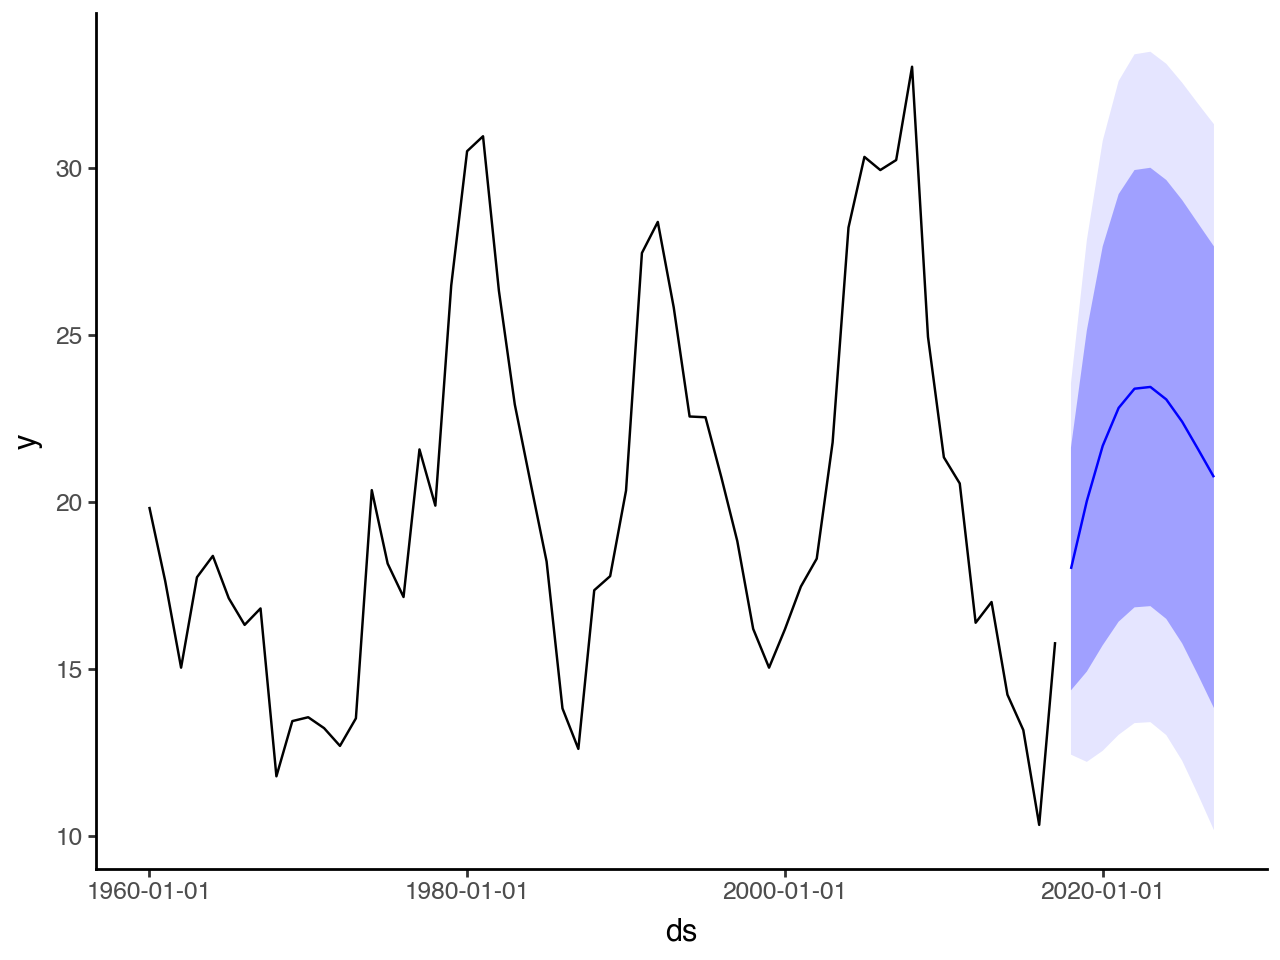

In [69]:
# plot of forecas
levels = [80, 95]
df_forecast = sf.predict(h=10, level=levels)

(ggplot(data=df_egypt, mapping=aes(x='ds', y='y')) + 
    geom_line() + 
    geom_line(inherit_aes=False, data=df_forecast, 
              mapping=aes(x='ds', y='AutoARIMA'), color='blue')+ 
    geom_ribbon(inherit_aes=False, data=df_forecast,
                mapping=aes(x='ds', ymin='AutoARIMA-lo-95', ymax='AutoARIMA-hi-95'), 
                alpha=0.1, fill='blue') + 
     geom_ribbon(inherit_aes=False, data=df_forecast,
                mapping=aes(x='ds', ymin='AutoARIMA-lo-80', ymax='AutoARIMA-hi-80'), 
                alpha=0.3, fill='blue') +
    theme_classic())

### Understanding ARIMA models 

Some important notes: 

1. If $c=0$ and $d=0$ (i.e, intercept is zero and there is no differencing), then long-term forecasts will go to zero. 
2. If $c=0$ and $d=1$ (i.e, intercept is zero and there first-order differencing), then long-term forecasts will go to non-zero constant.
3. If $c=0$ and $d=2$ (i.e, intercept is zero and there second-order differencing), then long-term forecasts will follow a straight line.
4. If $c\ne0$ and $d=0$ (i.e, intercept is non-zero and there is no differencing), then long-term forecasts will go to mean of the data.
5. Higher values of $d$ mean that prediction intervals increase in size with time. If $d=0$, long-term SD will be SD of historical data. 
6. Value of $p \ge 2$ allows the model to account for cyclic behaviour. 


### ACF and PACF plots

ACF and PACF plots can be used to determine appropriate values for $p$ and $q$ if the data are from ARIMA(p,d,0) or ARIMA(0,d,q) models. In other words, we can use autocorrelation plots to determine whether there the effects of residuals and/or observed values should be modelled and how many lags they should be considered over. 

To understand how to use ACF and PACF plots, it is first important to understand what affects autocorrelations in both plots. In traditional ACF plots, correlations represent total impacts (sum of direct and indirect causes). In PACF plots, correlations are caused only by direct effecs (i.e., effects that remain after removing lagged effects). In principle then, the following can be concluded: 

**AR(p) signature**

1.Data are only influenced by prior values up until lag $p$ (i.e., data follow AR(p,d,0)) if the ACF plot is exponentially decaying and the PACF plot shows a spike at lag $p$ and then quickly subsides to near-zero values afterwards. Note that the ACF is exponentially decaying because the direct (partial) correlations are being carried forward. 
2. When data follow AR(p) signature, oftentimes follows from slightly underdifferenced data. This is because AR(p) modelling acts as a soft form of differncing. Therefore, another signature to look for is a positive lag-1 correlation because AR(1) model acts as partial form of differencing. 

**MA(q) sigature**

ACF displays sharp cutoff at lag-k or ACF cuts off ta lag-k. MA signature is often associated with negative autocorrelation at lag-1, which tends to follow from overdifferenced data.

Reason for this is that MA(1) models partially cancels out overdifferencing. To see this, note that MA(1) or ARIMA(0,1,1) model is a simple SES model. This explanation doesn't go through the math, but here is the high-level explanation. Recall that ARIMA(0,1,1) means that

$$
\hat{y}_t = \mu y_{t-1} - \theta_1 \epsilon_{t-1}.
$$

If $\theta_1 = 1$, this corresponds to a SES moel with $\alpha=0$ which is simply predicts a constant value and so the differencing normally applied in a SES model is cancelled. If $\theta_1 = 0$, this corresponds to a random-walk model that leaves differencing alone. Values of $\theta_!$ between 0-1 correspond to partial cancellation of differencing. 

Data are only influenced by prior residuals up until lag $q$ (i.e., data follow AR(0,d,q)) if the PACF plot is exponentially decaying and there is a spike at lag $q$ in the ACF plot, but none beyond lag $q$. Thinking here is that, given there is little effect of prior values (as shown by the decay in the PACF plot), the observed correlations up until lag $q$ in the ACF plot are likely due to residuals.  

In [ ]:
### Other notes on ACF and APCF signatures
1. 

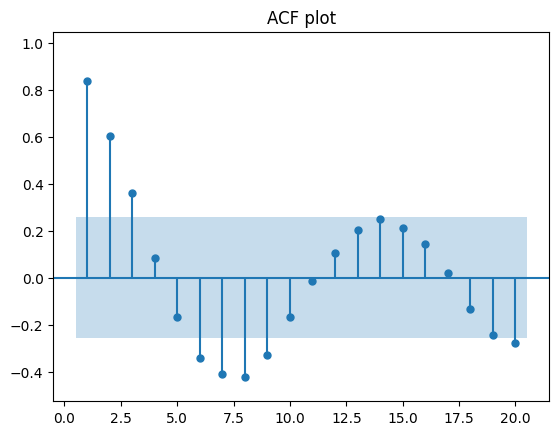

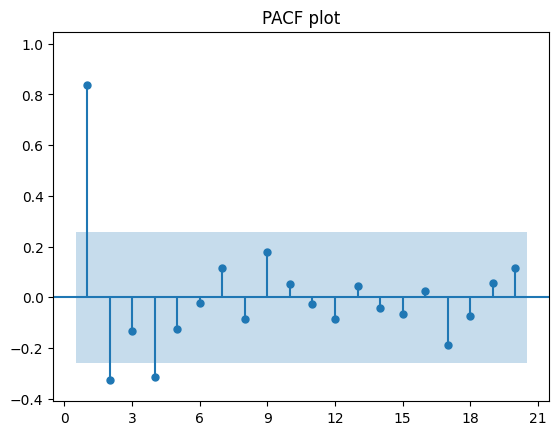

In [14]:
# ACF and PACF plots 
from matplotlib.ticker import MaxNLocator
df_egypt = pd.read_csv("data/raw/global_economy.csv", parse_dates=[2])
df_egypt = df_egypt.rename(columns={"Exports": "y"})
df_egypt = df_egypt.query("Code == 'EGY'").reset_index(drop=True)

fig, ax = plt.subplots()
fig = plot_acf(df_egypt["y"], lags=20, zero=False,
         bartlett_confint=False,
         ax=ax, title='ACF plot',
         auto_ylims=True)


fig, ax = plt.subplots()
fig = plot_pacf(df_egypt["y"], lags=20,
                zero=False,
                ax=ax, title='PACF plot',
                auto_ylims=True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

In [ ]:
# Using above plots, an ARIMA(4,0,0) model is shown to be just as good as the initial ARIMA(2,0,1) chosen by 
# AutoARIMA(), which had AICc = 294.29
from statsforecast.models import ARIMA

models = [ARIMA(order=(4, 0, 0))]

sf = StatsForecast(models=models, freq="Y", n_jobs=-1)

sf.fit(df=df_egypt[["ds", "y", "unique_id"]])

print(ARIMASummary(sf.fitted_[0, 0].model_))
coefs = deepcopy(sf.fitted_[0, 0].model_['coef'])
coefs["mean"] = coefs.pop("intercept")
print(f"Coefficients: {coefs}")
print(f"sigma^2     : {sf.fitted_[0, 0].model_['sigma2']:.2f}")
print(f"loglik      : {sf.fitted_[0, 0].model_['loglik']:.2f}")
print(f"aic         : {sf.fitted_[0, 0].model_['aic']:.2f}")
print(f"aicc        : {sf.fitted_[0, 0].model_['aicc']:.2f}")
print(f"bic         : {sf.fitted_[0, 0].model_['bic']:.2f}")


StatsForecast(models=[ARIMA])

ARIMA(4,0,0) with non-zero mean
Coefficients: {'ar1': np.float64(0.9860926696702997), 'ar2': np.float64(-0.17152908607851922), 'ar3': np.float64(0.1807250858264503), 'ar4': np.float64(-0.3282563957215513), 'mean': np.float64(20.098620303172236)}
sigma^2     : 7.88
loglik      : -140.53
aic         : 293.05
aicc        : 294.70
bic         : 305.41


## 9.6. Estimation and order selection 

1. Parameter estimation for ARIMA models is complex and so sligtly different parameters are returned by different softwares. 
2. Authors recommend using AICc for choosing models. 
3. Information criteria/fit statistics cannot be used to determine the differencing order. Because different values of $d$ yield different data, likeihoods across models would be maxizming fundamentally different data. Therefore, only use fit statistics to select values of p and q. 

## 9.7. ARIMA modelling in `statsforecast` 


Below is the default (Hyndman-Khandakar) algorithm underlying `ARIMA()`, though arguments can be changed within the function. 

1. Differencing order is constrained to $0 \le d \le 2$ using repeated KPSS tests. 
2. Values for p and q are then determining by minimizing the AICc after having differenced the data $d$ times. Initially, only four models are considered using a stepwise search: 
* ARIMA(0, d, 0)
* ARIMA(2, d, 2)
* ARIMA(1,d,0)
* ARIMA(0,d,1)

A constant ($c$) is included if $d = 2$. If $d \le 1$, the ARIMA(0,d,0) without a constant is considered. 

3. Model with smalled AICc is selected. 
4. Values of $p$ and $q$ arevaried from the currently selected model by $\pm 1$ with and without a constant. Current model is replaced with a variation should the AICc value be lower. 
5. Repeat steps 3-4 until convergence. 

Importantly, the algorithm stops searching the set of neighbor models immediately after finding a better-fitting variation. 

Approximations used in model exploration/fitting to expedite the process can be deactivated using  `approximate=False`. Algorithm can be directed to explore larger set of models by setting `stepwise=False`. 


### Modelling procedure 

The following steps should be followed when futting ARIMA model to non-seasonal time series data: 

1. Plot data and identify any unusual observations. 
2. Applying necessary transformations (e.g., Box-Cox) to stablize variance. 

**Hyndman-Khandakar**

3. Apply necessary amount of differencing as determined by unit-root testing. 
4. Examine ACF/PACF plots to determine whether AR and/or MA model is appropriate. 
5. Fit model and compare to neighbors (part of Hyndman-Khandakar algorithm)

6. Examine residuals for homogeneity and bias. Try out formal tests (portmanteau test). Experiment with alternative models if residuals do not have white noise structure. 
7. Once residuals look like white noise, calculate forecasts. 

##

### Portmanteau tests of residuals for ARIMA models

Pormanteau tests are more accurate if degrees of freedom are adjusted to account for number of parameters estimated by ARIMA model. For non-seasonal models, $K=p+q$, which can be subtracted from the initial number of parameters ($\ell$). When running `acorr_ljunbbox()`, pass K as value for `model_df` paramter. 

### Example: Central African Republic exports

1. Plot shows non-stationarity with overall decline. Although exports increased in 1994, this was short lived and further economic decline followed. 
2. Apparently no evidence for changing variability over time? 
3. Variability appears constant over time using first-order differences, though KPSS test is failed. 
4. PACF and ACF plots suggest initial models of ARIMA(2, 1,0) and ARIMA(0,1,3). IN addition to fitting these models, also use the stepwise default procedure and a more thorough procedure that searches a larger model space. 
5. Models show nearly identialy AICc values. That being said, will use ARIMA(3,1,0). 


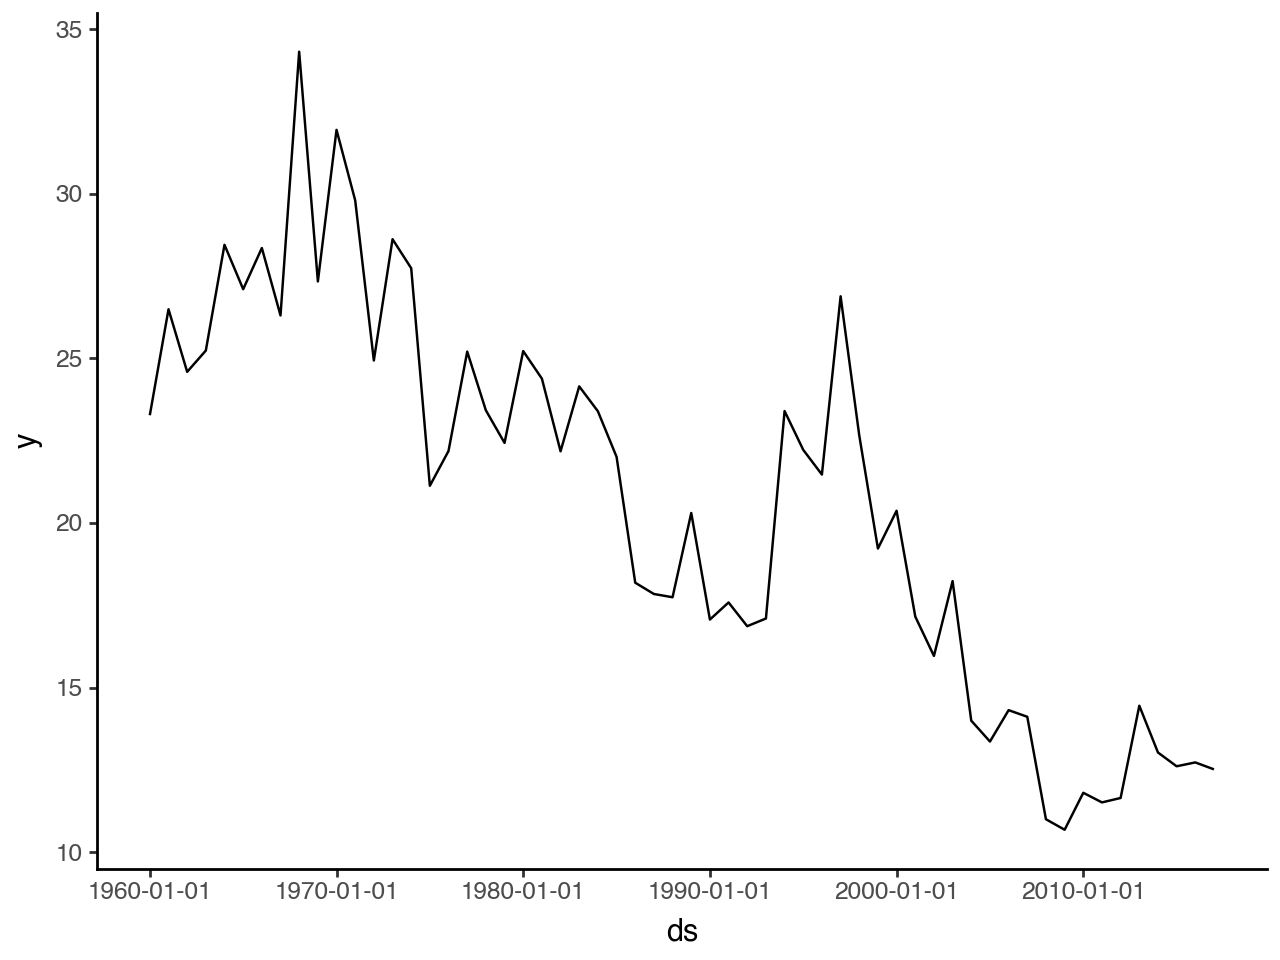

kpss_stat: 1.053, kpss_pvalue: 0.01
kpss_stat: 0.500, kpss_pvalue: 0.04


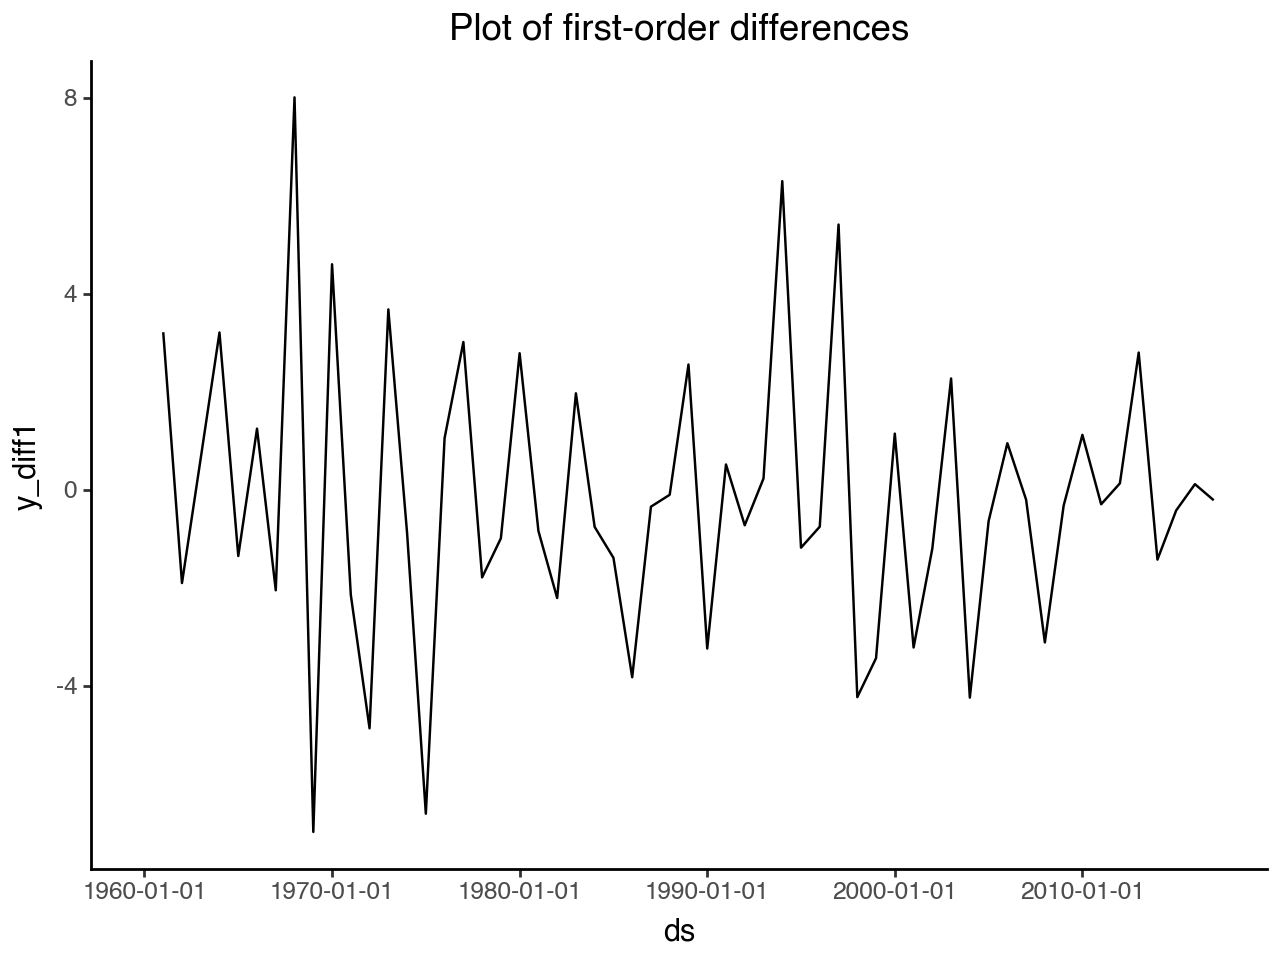

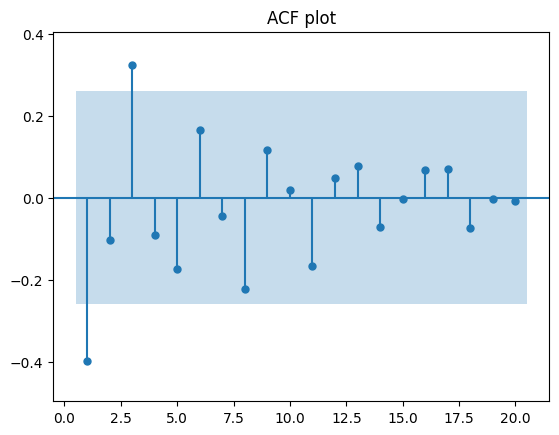

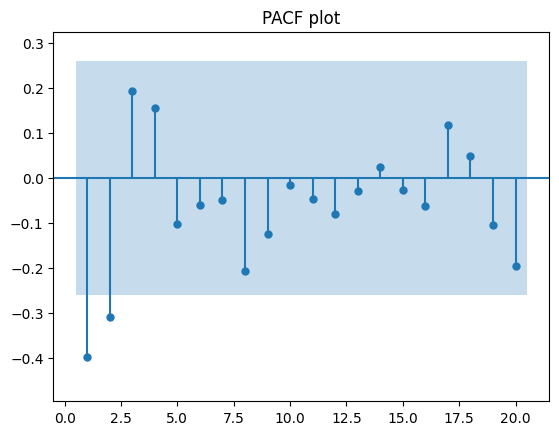

In [45]:
## Example: Central African Republic exports
from coreforecast.scalers import boxcox, boxcox_lambda


df_econ = pd.read_csv("data/raw/global_economy.csv", parse_dates=[2])
df_econ = df_econ.rename(columns={"Exports": "y"})
df_caf = df_econ.query("Code == 'CAF'").reset_index(drop=True)

# Step 1: Plot time series and look for unusual patterns
(ggplot(data=df_caf, mapping=aes(x='ds', y='y')) + 
    geom_line() + 
    scale_x_datetime(date_breaks='10 years') + 
    theme_classic())

# Step 3: Determine differencing to apply
# examine output with original data and differenced data 
df_caf["y_diff1"] = df_caf["y"].diff(1)

kpss_stat, kpss_pvalue, _, _ = kpss(df_caf["y"], nlags='auto')
print(f"kpss_stat: {kpss_stat:.3f}, kpss_pvalue: {kpss_pvalue:.2f}")

kpss_stat, kpss_pvalue, _, _ = kpss(df_caf["y"].diff(1)[1:], nlags='auto')
print(f"kpss_stat: {kpss_stat:.3f}, kpss_pvalue: {kpss_pvalue:.2f}")

(ggplot(data=df_caf, mapping=aes(x='ds', y='y_diff1')) + 
    geom_line() + 
    scale_x_datetime(date_breaks='10 years') +
    ggtitle(title="Plot of first-order differences") +  
    theme_classic())

# Step 4: Examine ACF and PACF plots to determine initial models 
fig, ax = plt.subplots()
fig = plot_acf(df_caf.loc[df_caf["y_diff1"].notna(), 'y_diff1'], lags=20, zero=False,
         bartlett_confint=False,
         ax=ax, title='ACF plot',
         auto_ylims=True)


fig, ax = plt.subplots()
fig = plot_pacf(df_caf.loc[df_caf["y_diff1"].notna(), 'y_diff1'], lags=20,
                zero=False,
                ax=ax, title='PACF plot',
                auto_ylims=True)


In [50]:
# Steps 4-5
models = [ARIMA(order=(2, 1, 0), alias="arima210"),
          ARIMA(order=(0, 1, 3), alias="arima013"),
          AutoARIMA(alias="stepwise"),
          AutoARIMA(stepwise=False, alias="search"),]

sf = StatsForecast(models=models, freq="A", n_jobs=-1)

# NOTE: differencing is applied internally 
sf.fit(df=df_caf[["ds", "y", "unique_id"]], target_col='y')

summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)

pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

StatsForecast(models=[arima210,arima013,stepwise,search])

,model,Orders,sigma2,loglik,aic,aicc,bic
0,search,"ARIMA(3,1,0)",6.518527,-133.005829,274.011658,274.780889,282.183863
1,arima210,"ARIMA(2,1,0)",6.706196,-134.269488,274.538975,274.991805,280.668129
2,arima013,"ARIMA(0,1,3)",6.536673,-133.130383,274.260766,275.029997,282.432971
3,stepwise,"ARIMA(2,1,2)",6.416703,-132.124031,274.248061,275.424532,284.463317


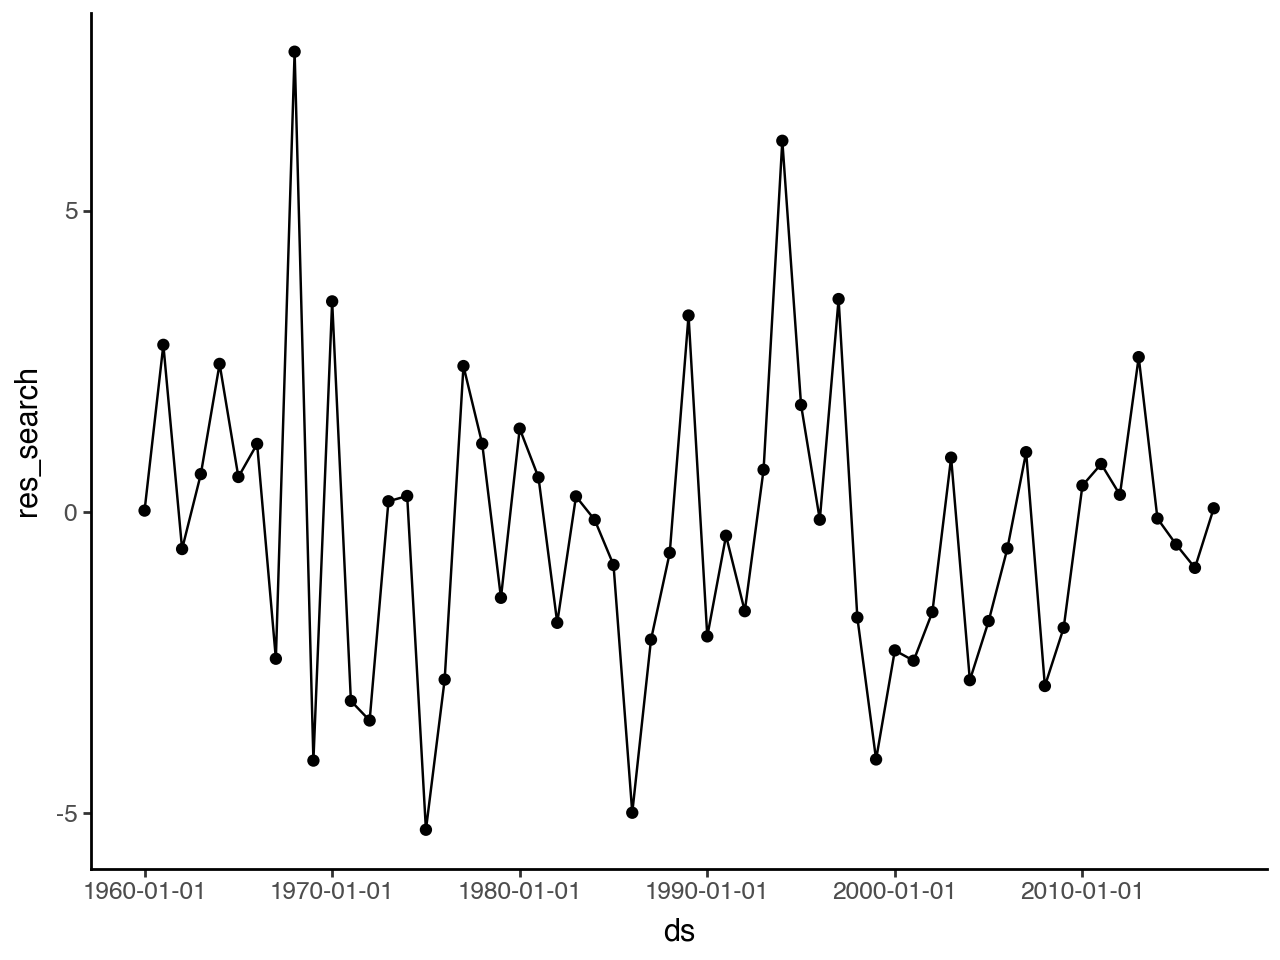

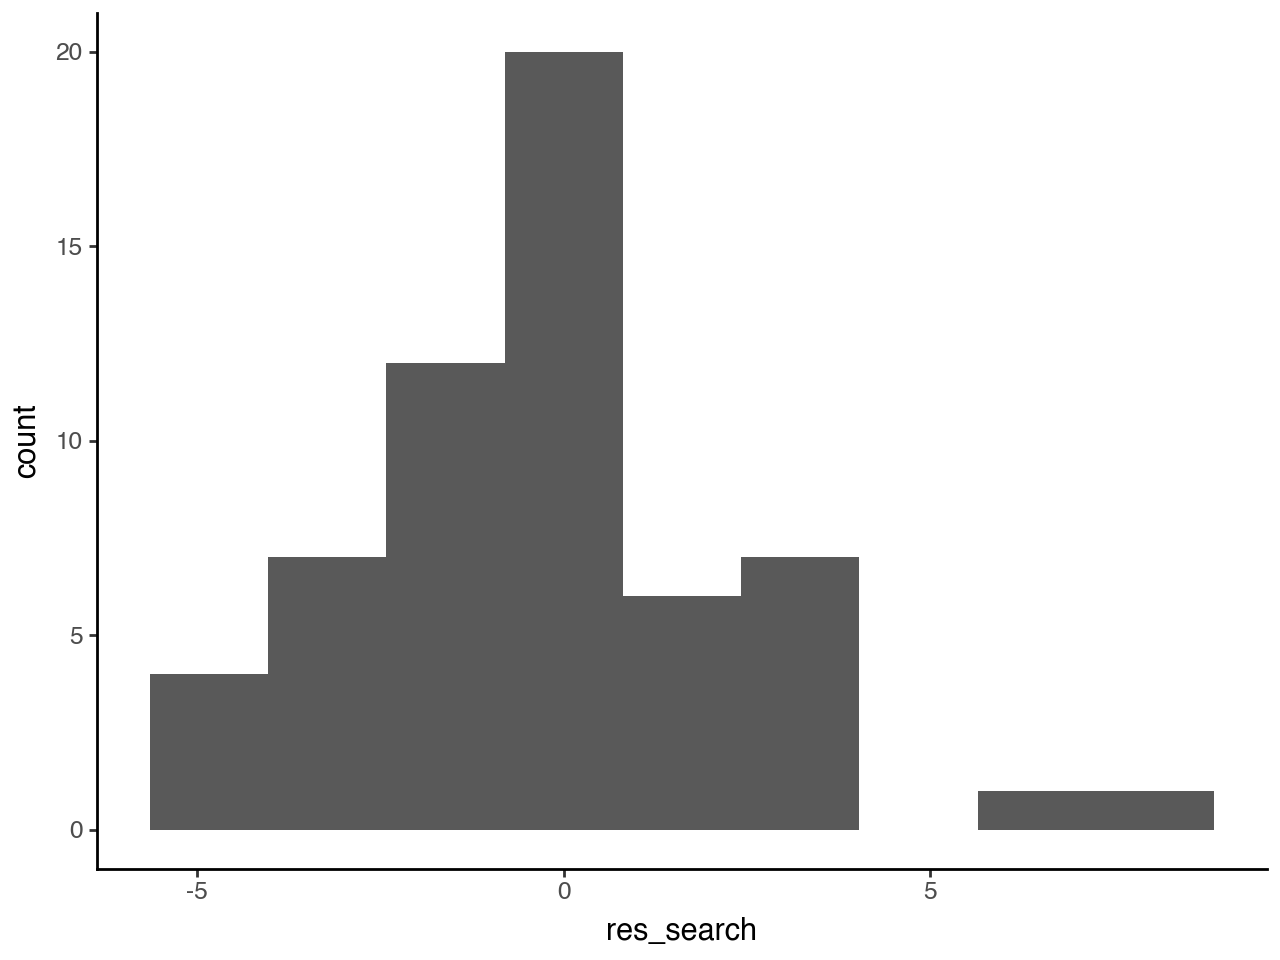

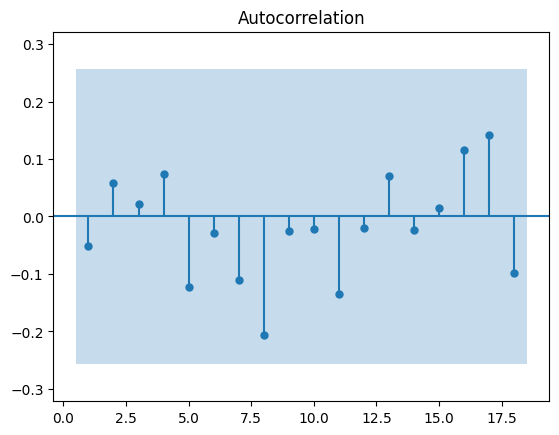

,lb_stat,lb_pvalue
10,5.703851,0.574723


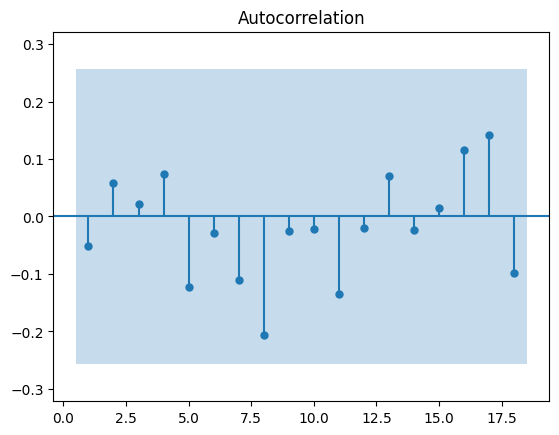

In [60]:
# Step 6: Examine forecasting residuals of ARIMA(3,1,0)
forecasts = sf.forecast(
    df=df_caf[["ds", "y", "unique_id"]], h=10, fitted=True, level=[80, 95])

df_fitted = sf.forecast_fitted_values()
insample_forecasts = df_fitted["search"]
df_fitted['res_search'] = df_fitted["y"] - insample_forecasts

# Residual over time 
(ggplot(data=df_fitted, mapping=aes(x='ds', y='res_search')) + 
    geom_line() + 
    geom_point() +
    theme_classic())

# Distribution of residuals
(ggplot(data=df_fitted, mapping=aes(x='res_search')) + 
    geom_histogram() + 
    theme_classic())

# Autocorrelation plot
plot_acf(df_fitted['res_search'], zero=False,
         bartlett_confint=False,
         auto_ylims=True)

# portmanteau test
acorr_ljungbox(df_fitted['res_search'], lags=[10], model_df=3)


### Understanding constants 

1. By default, `ARIMA()` sets $c=\mu=0$ when $d \gt 0$ and estimates $\mu$ when $d=0$ (here, $\mu$ will be close to the sample mean). Therefore, `include_mean=True` by default and only has an effect when d=0. Setting `include_mean=False` forces $\mu=c=0$. 
2. `include_drift=True` allows $\mu \ne 0$ when d=1. When $d \gt 1$, no constant is allowed, as the value could blow up in a quadratic model. 
3.  `AutoARIMA()` handles whether to include constant. By default, constant will be included it is improves AICc and $d \le1$$. If `allowdrift=False`, then constant is only allowed when d=0.  

## 9.8 Forecasting 

1. Prediction intervals are accurate to the extent that residuals are normally distributed and uncorrelated. Therefore, always examine ACF plots and histogram of residuals. If residuals are uncorrelated but not normally distributed, then use bootstrap intervals. 
2. For nonstationary data (i.e., whne $d \gt 1$ is required), forecasting variance will increase over time. 
3. Prediction intervals are overly conservative becase other sources of errors are not accounted for (e.g., variability in paramter estimates, uncertainty in model order, etc.). 

## 9.9. Seasonal ARIMA models 

In [ ]:
# notes below are from https://people.duke.edu/~rnau/seasarim.htm


ARIMA models are also capable of modelling seasonal trends. In the notation, this is reflected as ARIMA(p,d,q) (P,D,Q)$_m$, where upercase letters capture seasonal parts. As with the nons-seasonal components, determining the appropriate seasonal values for P, D, Q, is largely similar. 


### ACF/PACF
The seasonal AR and MA values can be determined by examining the seasonal lags in the PACF/ACF plots. As an example, an ARIMA(0,0,0)(0,0,1)$_{12}$ model would cause a spike at lag 12 in the ACF plot and exponential decay in the PACF plot (that is, the spike in the overall plot is likely not due to any lagged effect). Similarly, an ARIMA(0,0,0)(1,0,0)$_{12}$ model would show a PACF plot that has a spike at lag 12 and an ACF plot that shows exponential decay. 

### Example: Monthly US leisure and hospitality employment 
1. Plot shows data are not stationaary due to 1) a nonlinear trend and 2) seasonality. Employment increases throughout the year and peaks in the summer from June-August, and then decliens from Sep-Dec. Therefore, the first form of differencing to apply is seasonal and apply further differencing if required. 
2.  ACF + PACF plots: Spike at lag 2 in ACF suggests a non-seasonal MA(2) process e

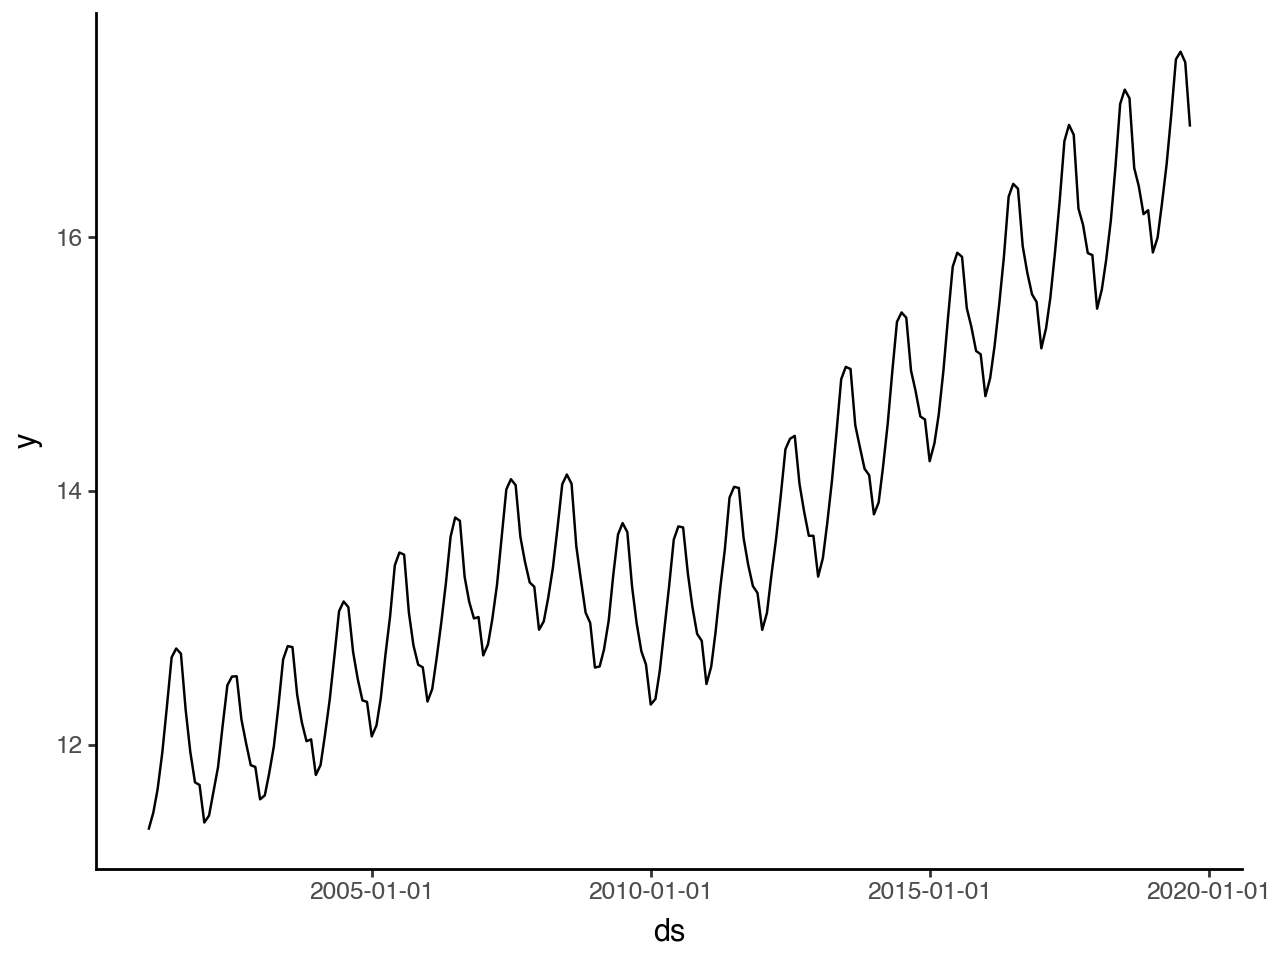

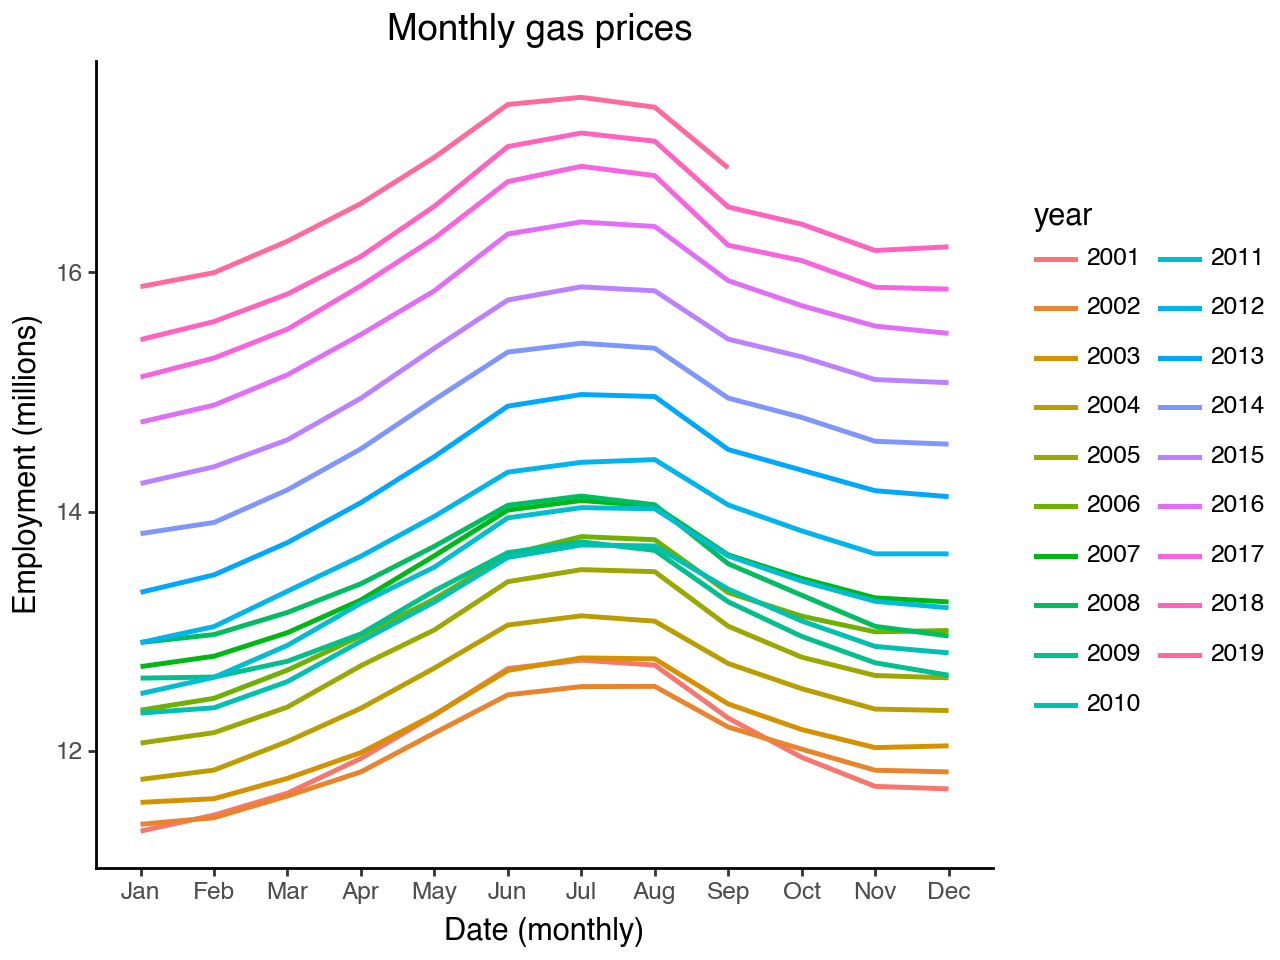

In [4]:
df_us_emp = pd.read_csv("data/raw/us_employment.csv", parse_dates=["ds"])

df_leisure = df_us_emp.query(
    "unique_id == 'Leisure and Hospitality' and ds.dt.year > 2000").reset_index(drop=True)

df_leisure["y"] /= 1000

(ggplot(data=df_leisure, mapping=aes(x='ds', y='y')) + 
    geom_line() + 
    theme_classic())

# plot value by month 
# compute average monthly gass prices
df_leisure['year'] = df_leisure['ds'].dt.year.astype(str)
df_leisure['month'] = df_leisure['ds'].dt.strftime('%b')   # Full month name (e.g. January, June)

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Convert to ordered categorical
df_leisure['month'] = pd.Categorical(df_leisure['month'], 
                                            categories=month_order, 
                                            ordered=True)

(ggplot(data=df_leisure, 
        mapping=aes(x='month', y='y', group='year', color='year')) + 
  geom_line(size=1) + 
  labs(x='Date (monthly)', y="Employment (millions)") + 
  ggtitle(title='Monthly gas prices ') + 
  theme_classic())

kpss_stat: 0.611, kpss_pvalue: 0.02


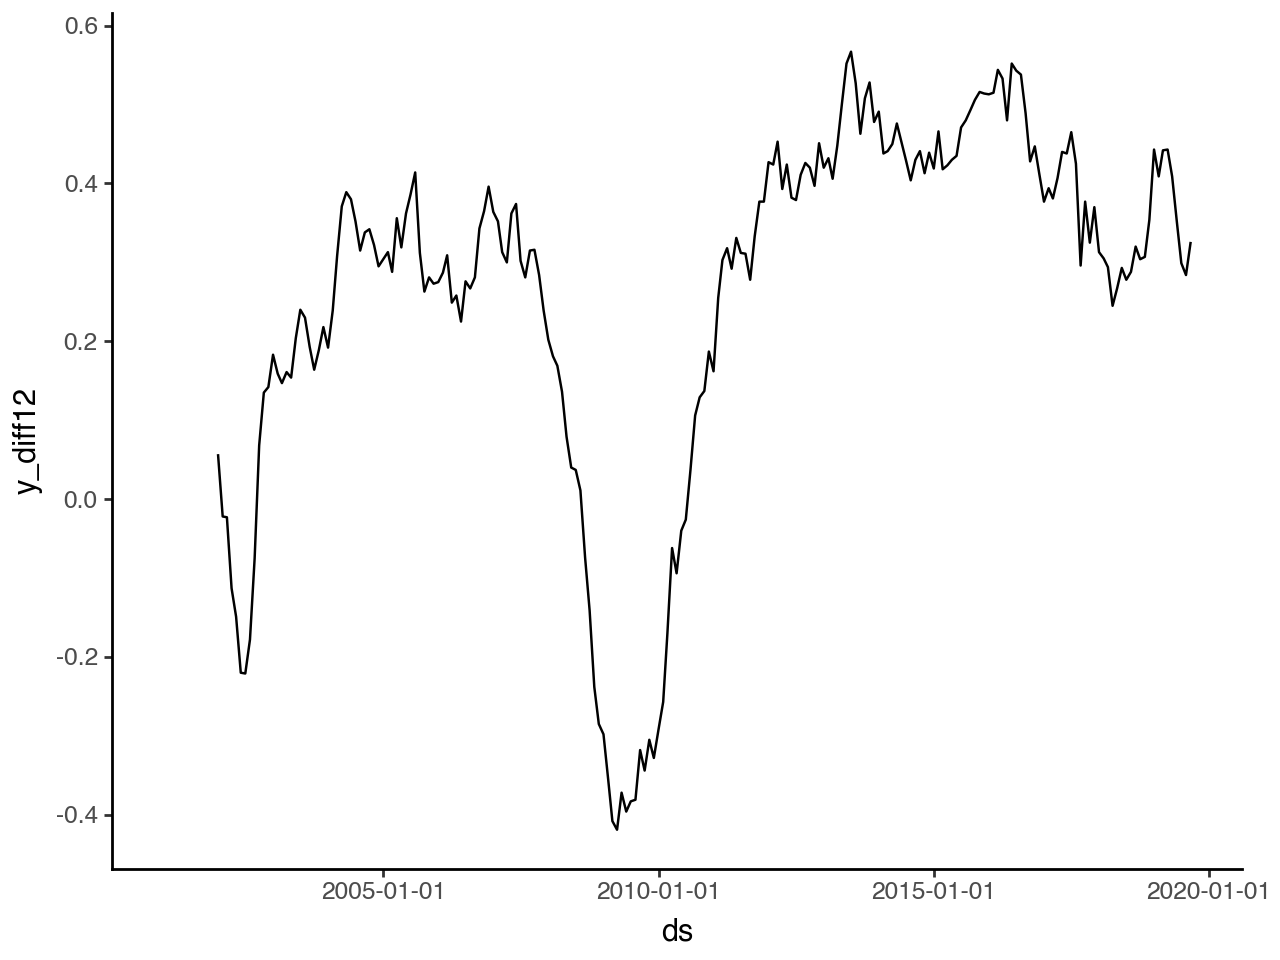

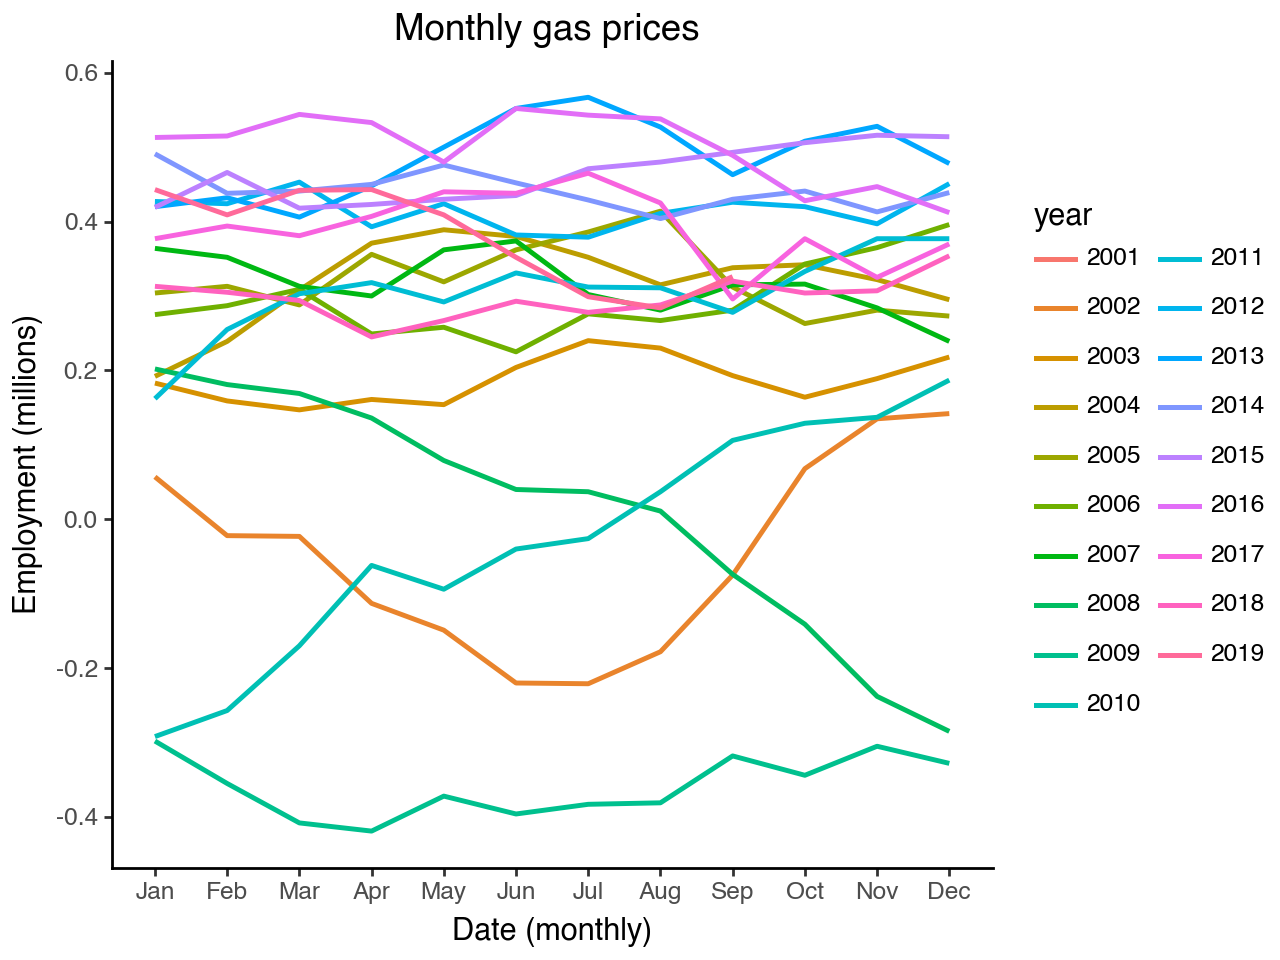

In [6]:
# Step 1: Apply seasonal differencing and determine whether further differencing is required 
df_leisure['y_diff12'] = df_leisure['y'].diff(periods=12)

# data are clearly still not stationary 
kpss_stat, kpss_pvalue, _, _ = kpss(df_leisure['y'].diff(periods=12)[12:], nlags='auto')
print(f"kpss_stat: {kpss_stat:.3f}, kpss_pvalue: {kpss_pvalue:.2f}")

(ggplot(data=df_leisure, mapping=aes(x='ds', y='y_diff12')) + 
    geom_line() + 
    theme_classic())

(ggplot(data=df_leisure, 
        mapping=aes(x='month', y='y_diff12', group='year', color='year')) + 
  geom_line(size=1) + 
  labs(x='Date (monthly)', y="Employment (millions)") + 
  ggtitle(title='Monthly gas prices ') + 
  theme_classic())


kpss_stat: 0.080, kpss_pvalue: 0.10


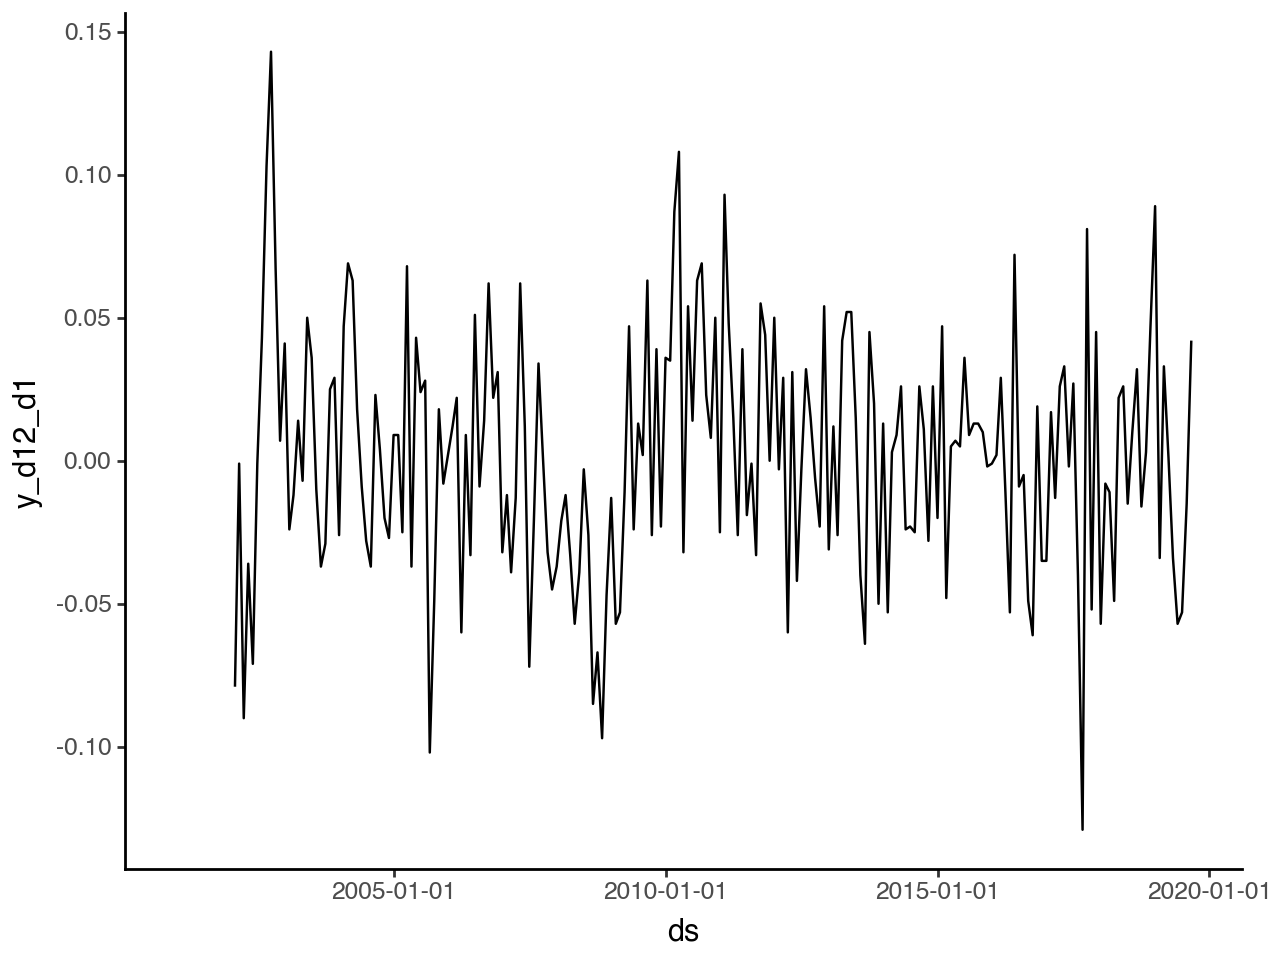

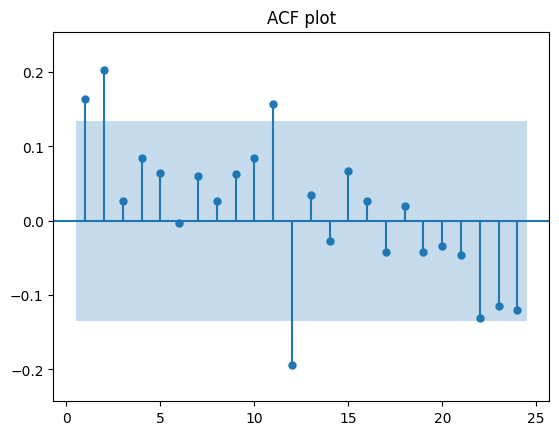

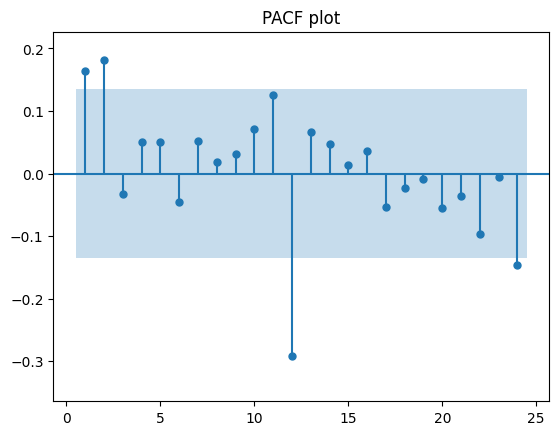

In [8]:
df_leisure['y_d12_d1'] = df_leisure['y_diff12'].diff(periods=1)
df_leisure['y_d12_d2'] = df_leisure['y_diff12'].diff(periods=1)

kpss_stat, kpss_pvalue, _, _ = kpss(df_leisure['y_d12_d1'].dropna().values, nlags='auto')
print(f"kpss_stat: {kpss_stat:.3f}, kpss_pvalue: {kpss_pvalue:.2f}")

(ggplot(data=df_leisure, mapping=aes(x='ds', y='y_d12_d1')) + 
    geom_line() + 
    theme_classic())

# plot acf and PACF 
fig, ax = plt.subplots()
plot_acf(df_leisure.loc[df_leisure["y_d12_d1"].notna(), 'y_d12_d1'], lags=24, zero=False,
         bartlett_confint=False,
         ax=ax, title='ACF plot',
         auto_ylims=True)

fig, ax = plt.subplots()
plot_pacf(df_leisure.loc[df_leisure["y_d12_d1"].notna(), 'y_d12_d1'], lags=24,
                zero=False,
                ax=ax, title='PACF plot',
                auto_ylims=True)
